# GTEx — индекс τ


In [163]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd

PROJ_ROOT = Path.cwd().resolve()
if not (PROJ_ROOT / "data" / "processed").is_dir():
    PROJ_ROOT = PROJ_ROOT.parent
if not (PROJ_ROOT / "data" / "processed").is_dir():
    raise FileNotFoundError("Укажите корень репозитория с data/processed.")

PROC = PROJ_ROOT / "data" / "processed"
PATH_GTEX_COUNTS = PROC / "gtex_mature_counts_filtered.parquet"
PATH_GTEX_META = PROC / "gtex_mature_metadata.parquet"
OUT_GTEX = PROJ_ROOT / "pipeline_python" / "gtex_tau_out"
OUT_GTEX.mkdir(parents=True, exist_ok=True)

MIN_GTEX_SMTS_N = 10
PYDESEQ2_VST_FIT = "mean"  # как в Python-части TCGA; в R — local

for p in (PATH_GTEX_COUNTS, PATH_GTEX_META):
    if not p.is_file():
        raise FileNotFoundError(p)
print("PROJ_ROOT:", PROJ_ROOT)


PROJ_ROOT: /Users/neuropromotion/Desktop/miRNA/bulk_review


In [164]:
meta = pd.read_parquet(PATH_GTEX_META)
# идентификатор образца в колонках counts
if "SAMPID" in meta.columns:
    meta = meta.rename(columns={"SAMPID": "sample_id"})
elif "sample_barcode" in meta.columns:
    meta = meta.rename(columns={"sample_barcode": "sample_id"})
else:
    raise ValueError("В GTEx metadata ожидается SAMPID или sample_barcode")

if "SMTS" not in meta.columns:
    raise ValueError("Нужна колонка SMTS (ткань GTEx)")

meta["sample_id"] = meta["sample_id"].astype(str)
meta["SMTS"] = meta["SMTS"].astype(str)

smts_n = meta.groupby("SMTS").size()
eligible_smts = smts_n[smts_n >= MIN_GTEX_SMTS_N].index
meta_elig = meta[meta["SMTS"].isin(eligible_smts)].copy()
print("образцов в meta:", len(meta), "| после SMTS ≥", MIN_GTEX_SMTS_N, ":", len(meta_elig))
print("SMTS (eligible):", len(eligible_smts))


образцов в meta: 16761 | после SMTS ≥ 10 : 16761
SMTS (eligible): 30


In [165]:
meta = meta[['sample_id', 'SMTS']]
meta.head()

,sample_id,SMTS
0,GTEX-1117F-0005-SM-GMJZF,Blood
1,GTEX-1117F-0011-R3a-SM-GM3E3,Brain
2,GTEX-1117F-0011-R7a-SM-GLFXK,Brain
3,GTEX-1117F-0226-SM-DEURW,Adipose Tissue
4,GTEX-1117F-0426-SM-GAPMD,Muscle


In [166]:
g = pd.read_parquet(PATH_GTEX_COUNTS)
if "mature_name" not in g.columns:
    raise ValueError("В counts должна быть колонка mature_name")
        
sample_cols = [c for c in g.columns if c != "mature_name"]
g = g.set_index("mature_name")
# строки = образцы, столбцы = miRNA (как для PyDESeq2)
wide = g[sample_cols].T
wide.index = wide.index.astype(str)
wide = wide.loc[wide.index.isin(meta_elig["sample_id"])]
print("wide (samples × miRNA):", wide.shape)

smt_map = meta_elig.drop_duplicates("sample_id").set_index("sample_id")["SMTS"]
smts = smt_map.reindex(wide.index)
if smts.isna().any():
    wide = wide.loc[smts.notna()]
    smts = smts.loc[wide.index]
print("с SMTS:", len(wide))


wide (samples × miRNA): (16761, 622)
с SMTS: 16761


In [167]:
wide['hsa-miR-325'].var()

np.float64(0.0044589603749697945)

In [219]:
wide

mature_name,hsa-miR-200a-5p,hsa-miR-429,hsa-miR-551a,hsa-miR-34a-5p,hsa-miR-552-3p,hsa-miR-552-5p,hsa-miR-5581-3p,hsa-miR-30d-5p,hsa-miR-30e-3p,hsa-miR-30b-5p,...,hsa-miR-2114-5p,hsa-miR-2114-3p,hsa-miR-224-3p,hsa-miR-224-5p,hsa-miR-452-3p,hsa-miR-452-5p,hsa-miR-105-3p,hsa-miR-105-5p,hsa-miR-200b-5p,SMTS
GTEX-1117F-0005-SM-GMJZF,0.0,1.0,1.0,0.0,0.0,0.0,0.0,37.0,48.0,824.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Blood
GTEX-1117F-0011-R3a-SM-GM3E3,0.0,2.0,0.0,0.0,34.0,10.0,3.0,4136.0,2273.0,8082.0,...,0.0,0.0,1.0,0.0,0.0,19.0,3.0,365.0,0.0,Brain
GTEX-1117F-0011-R7a-SM-GLFXK,0.0,10.0,0.0,3.0,109.0,37.0,1.0,2173.0,919.0,5832.0,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,54.0,2.0,Brain
GTEX-1117F-0226-SM-DEURW,0.0,31.0,0.0,0.0,0.0,0.0,0.0,345.0,414.0,440.0,...,0.0,0.0,6.0,86.0,4.0,53.0,0.0,0.0,9.0,Adipose Tissue
GTEX-1117F-0426-SM-GAPMD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1368.0,1478.0,1749.0,...,0.0,0.0,2.0,14.0,0.0,11.0,0.0,0.0,0.0,Muscle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GTEX-ZZPU-2126-SM-DEUQ2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1160.0,1666.0,407.0,...,0.0,0.0,1.0,3.0,0.0,14.0,0.0,0.0,3.0,Ovary
GTEX-ZZPU-2226-SM-EAIMP,141.0,712.0,0.0,0.0,0.0,0.0,0.0,784.0,411.0,776.0,...,0.0,0.0,25.0,908.0,24.0,205.0,0.0,0.0,98.0,Vagina
GTEX-ZZPU-2426-SM-GEGOG,0.0,78.0,0.0,0.0,0.0,0.0,0.0,792.0,697.0,1407.0,...,0.0,0.0,8.0,218.0,6.0,43.0,0.0,0.0,4.0,Blood Vessel
GTEX-ZZPU-2626-SM-F4GMZ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,505.0,623.0,1103.0,...,0.0,0.0,1.0,24.0,0.0,10.0,0.0,0.0,0.0,Muscle


In [168]:
try:
    from pydeseq2.dds import DeseqDataSet
except ImportError as e:
    raise ImportError("pip install pydeseq2") from e

mir_cols = list(wide.columns)
X = np.round(np.maximum(wide.to_numpy(dtype=float), 0.0)).astype(np.int64)
counts_df = pd.DataFrame(X, index=wide.index, columns=mir_cols)
meta_dd = pd.DataFrame(index=wide.index)

dds = DeseqDataSet(
    counts=counts_df,
    metadata=meta_dd,
    design="~1",
    fit_type=PYDESEQ2_VST_FIT,
    quiet=True,
)
dds.vst(use_design=False, fit_type=PYDESEQ2_VST_FIT)
vst = pd.DataFrame(
    np.asarray(dds.layers["vst_counts"], dtype=float),
    index=wide.index,
    columns=mir_cols,
)
vst["_SMTS"] = smts.values
print("VST fit_type:", PYDESEQ2_VST_FIT)


VST fit_type: mean


In [169]:
# медиана VST по SMTS → линейная шкала → τ (как в R)
med_vst = vst.drop(columns=["_SMTS"]).groupby(vst["_SMTS"], dropna=False).mean()

lin = np.maximum(2.0 ** med_vst.to_numpy(dtype=float) - 1.0, 0.0)
lin_df = pd.DataFrame(lin, index=med_vst.index, columns=med_vst.columns)

'''
def tau_score(x: np.ndarray) -> float:
    x = np.maximum(np.asarray(x, dtype=float), 0.0)
    if x.size < 2:
        return float("nan")
    mx = np.nanmax(x)
    if not np.isfinite(mx) or mx <= 0:
        return float("nan")
    xn = x / mx
    return float(np.nansum(1.0 - xn) / (x.size - 1))
'''
def tau_score(x: np.ndarray) -> float:
    # Удаляем NaN перед расчетом, чтобы они не портили N (x.size)
    x = x[~np.isnan(x)]
    x = np.maximum(x, 0.0)
    
    n = x.size
    if n < 2:
        return np.nan
        
    mx = np.max(x)
    
    # Если макс 0 — значит экспрессии нет совсем. 
    # По логике Tau это либо NaN, либо 0 (не специфичен нигде). Обычно ставят NaN.
    if mx <= 0 or not np.isfinite(mx):
        return np.nan
    
    # Нормализация
    xn = x / mx
    # Сумма (1 - x_i/max) / (n - 1)
    return np.sum(1.0 - xn) / (n - 1)

tau_series = lin_df.apply(lambda col: tau_score(col.values), axis=0)
tau_gtex_df = (
    pd.DataFrame({"mature_name": tau_series.index.astype(str), "tau_gtex": tau_series.values})
    .sort_values("tau_gtex", ascending=False, na_position="last")
    .reset_index(drop=True)
)
tau_gtex_df.tail(15)


,mature_name,tau_gtex
607,hsa-miR-325,NaN
608,hsa-miR-652-5p,NaN
609,hsa-miR-1912-5p,NaN
610,hsa-miR-1912-3p,NaN
611,hsa-miR-1911-3p,NaN
612,hsa-miR-766-5p,NaN
613,hsa-miR-106a-5p,NaN
614,hsa-miR-503-3p,NaN
615,hsa-miR-504-3p,NaN
616,hsa-miR-892c-3p,NaN


In [170]:
num_cols = [x for x in vst.columns if x != '_SMTS']
np.sum(vst[num_cols].var(axis=0) == 0)

np.int64(0)

In [171]:
vst['hsa-miR-219b-3p'].var()

np.float64(2.039172357551019)

In [172]:
mask = lin_df.max(axis=0) > 0
lin_df_filtered = lin_df.loc[:, mask]

In [173]:
wide.var(axis=0)[(wide.var(axis=0) > 0)]

mature_name
hsa-miR-200a-5p    7.684211e+05
hsa-miR-429        1.432251e+06
hsa-miR-551a       1.292910e+00
hsa-miR-34a-5p     5.669794e+02
hsa-miR-552-3p     7.498700e+02
                       ...     
hsa-miR-452-3p     2.731131e+02
hsa-miR-452-5p     9.380433e+03
hsa-miR-105-3p     1.234348e+00
hsa-miR-105-5p     4.992323e+03
hsa-miR-200b-5p    1.107351e+04
Length: 622, dtype: float64

<Axes: >

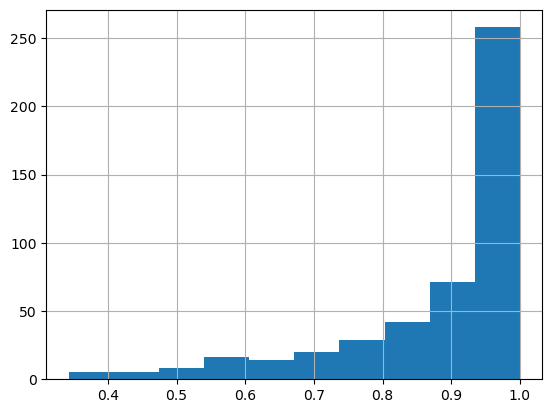

In [174]:
tau_gtex_df['tau_gtex'].hist()

In [204]:
wide["SMTS"].value_counts().head(20)

SMTS
Brain             3005
Skin              1611
Esophagus         1454
Blood Vessel      1191
Adipose Tissue     917
Colon              828
Heart              770
Blood              693
Muscle             663
Thyroid            644
Lung               546
Nerve              427
Testis             421
Stomach            387
Pancreas           377
Breast             346
Pituitary          314
Adrenal Gland      287
Prostate           268
Spleen             260
Name: count, dtype: int64

In [ ]:
# Высокоэкспрессирующие SMTS (аналог pref_tissue_highq в TCGA.ipynb): медиана VST по образцам в группе.
# Для каждой miRNA — медианы по всем SMTS; ткань «в хвосте», если её медиана ≥ q-квантиля этого набора медиан.

TOP_GROUP_QUANTILE = 0.97   

_smts = meta.drop_duplicates("sample_id").set_index("sample_id")[["SMTS"]]
_df = vst.join(_smts, how="inner")
if len(_df) != len(vst):
    raise ValueError("После join с meta число строк vst изменилось — проверьте sample_id.")

META_FOR_GROUP = ["SMTS"]
_mir = [c for c in _df.columns if c not in META_FOR_GROUP]
_med_smts = _df.groupby("SMTS", dropna=False)[_mir].median()


def _high_groups_str(med_by_group: pd.DataFrame, mir: str, q: float) -> str:
    if mir not in med_by_group.columns:
        return ""
    v = med_by_group[mir].dropna()
    if v.empty:
        return ""
    thr = float(v.quantile(q))
    high = v[v >= thr].index.astype(str).sort_values()
    return ";".join(high)


tau_gtex_df["pref_smts_highq"] = tau_gtex_df["mature_name"].apply(
    lambda m: _high_groups_str(_med_smts, m, TOP_GROUP_QUANTILE)
)
tau_gtex_df[["mature_name", "tau_gtex", "annotation", "pref_smts_highq"]].head(10)

/var/folders/np/46xyw0ds0t7g3v5c2ywcpmpc0000gn/T/ipykernel_40760/684012787.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tau_gtex_df["pref_smts_highq"] = tau_gtex_df["mature_name"].apply(


,mature_name,tau_gtex,annotation,pref_smts_highq
0,hsa-miR-584-3p,1.0,specific,Adipose Tissue;Adrenal Gland;Bladder;Blood;Blo...
1,hsa-miR-372-5p,1.0,specific,Testis
2,hsa-miR-3144-3p,1.0,specific,Adipose Tissue;Adrenal Gland;Bladder;Blood;Blo...
3,hsa-miR-3663-5p,1.0,specific,Testis
4,hsa-miR-504-3p,1.0,specific,Adipose Tissue;Adrenal Gland;Bladder;Blood;Blo...
5,hsa-miR-3145-5p,1.0,specific,Adipose Tissue;Adrenal Gland;Bladder;Blood;Blo...
6,hsa-miR-556-3p,1.0,specific,Adipose Tissue;Adrenal Gland;Bladder;Blood;Blo...
8,hsa-miR-216a-3p,1.0,specific,Pancreas
9,hsa-miR-3619-3p,1.0,specific,Blood
11,hsa-miR-1286,1.0,specific,Brain


# PLOTS

In [162]:
tau_gtex_df

,mature_name,tau_gtex,annotation,pref_smts_highq
1,hsa-miR-372-5p,1.000000,specific,Testis
3,hsa-miR-3663-5p,1.000000,specific,Testis
8,hsa-miR-216a-3p,1.000000,specific,Pancreas
9,hsa-miR-3619-3p,1.000000,specific,Blood
11,hsa-miR-1286,1.000000,specific,Brain
...,...,...,...,...
570,hsa-miR-26a-5p,0.439564,intermediate,Ovary
571,hsa-miR-374a-3p,0.429119,intermediate,Fallopian Tube
572,hsa-miR-574-3p,0.424782,intermediate,Pituitary
573,hsa-miR-152-3p,0.339135,intermediate,Skin


In [ ]:
wide['mature_name'] = wide.index
wide.sort_values('mature_name', inplace=True)
wide.pop('mature_name')
wide.head()

mature_name,hsa-miR-200a-5p,hsa-miR-429,hsa-miR-551a,hsa-miR-34a-5p,hsa-miR-552-3p,hsa-miR-552-5p,hsa-miR-5581-3p,hsa-miR-30d-5p,hsa-miR-30e-3p,hsa-miR-30b-5p,...,hsa-miR-514a-3p,hsa-miR-2114-5p,hsa-miR-2114-3p,hsa-miR-224-3p,hsa-miR-224-5p,hsa-miR-452-3p,hsa-miR-452-5p,hsa-miR-105-3p,hsa-miR-105-5p,hsa-miR-200b-5p
GTEX-1117F-0005-SM-GMJZF,0.0,1.0,1.0,0.0,0.0,0.0,0.0,37.0,48.0,824.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
GTEX-1117F-0011-R3a-SM-GM3E3,0.0,2.0,0.0,0.0,34.0,10.0,3.0,4136.0,2273.0,8082.0,...,0.0,0.0,0.0,1.0,0.0,0.0,19.0,3.0,365.0,0.0
GTEX-1117F-0011-R7a-SM-GLFXK,0.0,10.0,0.0,3.0,109.0,37.0,1.0,2173.0,919.0,5832.0,...,42.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,54.0,2.0
GTEX-1117F-0226-SM-DEURW,0.0,31.0,0.0,0.0,0.0,0.0,0.0,345.0,414.0,440.0,...,0.0,0.0,0.0,6.0,86.0,4.0,53.0,0.0,0.0,9.0
GTEX-1117F-0426-SM-GAPMD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1368.0,1478.0,1749.0,...,0.0,0.0,0.0,2.0,14.0,0.0,11.0,0.0,0.0,0.0


In [190]:
meta_final = meta[meta['sample_id'].isin(wide.index)]
meta_final.sort_values('sample_id', inplace=True)
meta_final

,sample_id,SMTS
0,GTEX-1117F-0005-SM-GMJZF,Blood
1,GTEX-1117F-0011-R3a-SM-GM3E3,Brain
2,GTEX-1117F-0011-R7a-SM-GLFXK,Brain
3,GTEX-1117F-0226-SM-DEURW,Adipose Tissue
4,GTEX-1117F-0426-SM-GAPMD,Muscle
...,...,...
16756,GTEX-ZZPU-2126-SM-DEUQ2,Ovary
16757,GTEX-ZZPU-2226-SM-EAIMP,Vagina
16758,GTEX-ZZPU-2426-SM-GEGOG,Blood Vessel
16759,GTEX-ZZPU-2626-SM-F4GMZ,Muscle


array(['Blood', 'Brain', 'Brain', ..., 'Blood Vessel', 'Muscle',
       'Adipose Tissue'], shape=(16761,), dtype=object)

In [197]:
wide['SMTS'] = meta_final['SMTS'].values
wide.head()


mature_name,hsa-miR-200a-5p,hsa-miR-429,hsa-miR-551a,hsa-miR-34a-5p,hsa-miR-552-3p,hsa-miR-552-5p,hsa-miR-5581-3p,hsa-miR-30d-5p,hsa-miR-30e-3p,hsa-miR-30b-5p,...,hsa-miR-2114-5p,hsa-miR-2114-3p,hsa-miR-224-3p,hsa-miR-224-5p,hsa-miR-452-3p,hsa-miR-452-5p,hsa-miR-105-3p,hsa-miR-105-5p,hsa-miR-200b-5p,SMTS
GTEX-1117F-0005-SM-GMJZF,0.0,1.0,1.0,0.0,0.0,0.0,0.0,37.0,48.0,824.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Blood
GTEX-1117F-0011-R3a-SM-GM3E3,0.0,2.0,0.0,0.0,34.0,10.0,3.0,4136.0,2273.0,8082.0,...,0.0,0.0,1.0,0.0,0.0,19.0,3.0,365.0,0.0,Brain
GTEX-1117F-0011-R7a-SM-GLFXK,0.0,10.0,0.0,3.0,109.0,37.0,1.0,2173.0,919.0,5832.0,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,54.0,2.0,Brain
GTEX-1117F-0226-SM-DEURW,0.0,31.0,0.0,0.0,0.0,0.0,0.0,345.0,414.0,440.0,...,0.0,0.0,6.0,86.0,4.0,53.0,0.0,0.0,9.0,Adipose Tissue
GTEX-1117F-0426-SM-GAPMD,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1368.0,1478.0,1749.0,...,0.0,0.0,2.0,14.0,0.0,11.0,0.0,0.0,0.0,Muscle


In [199]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

TOP_N = 15
OTHER = "Other types"
MISSING = "<missing>"


def counts_for_pie(series: pd.Series, top_n: int = TOP_N):
    s = series.fillna(MISSING).astype(str)
    vc = s.value_counts()

    if len(vc) <= top_n:
        return vc.index.tolist(), vc.values.astype(float)

    top = vc.iloc[:top_n]
    rest = vc.iloc[top_n:].sum()

    labels = top.index.tolist() + [OTHER]
    sizes = np.append(top.values.astype(float), float(rest))

    return labels, sizes


def _cmap(name):
    try:
        return plt.colormaps[name]
    except:
        return plt.cm.get_cmap(name)


def plot_pie_single(
    data: pd.DataFrame,
    col: str,
    title_prefix: str = "Samples",
    save_path: str = None,
):
    
    fig, ax = plt.subplots(figsize=(10, 8), dpi=120)
    fig.patch.set_facecolor("#fafafa")

    cmap = _cmap("tab20b")

    if col not in data.columns:
        raise ValueError(f"{col} not found in dataframe")

    labels, sizes = counts_for_pie(data[col], TOP_N)

    n = len(labels)
    colors = [cmap(i / max(n-1, 1)) for i in range(n)]

    for i, lab in enumerate(labels):
        if lab in (OTHER, MISSING):
            colors[i] = (0.82, 0.82, 0.86, 1.0)

    wedges, texts, autotexts = ax.pie(
        sizes,
        labels=None,
        autopct=lambda p: f"{p:.1f}%" if p >= 2 else "",
        pctdistance=0.72,
        colors=colors,
        wedgeprops=dict(
            width=0.45,
            edgecolor="white",
            linewidth=0.8
        ),
        startangle=90,
    )

    for t in autotexts:
        t.set_fontsize(9)
        t.set_color("#222")

    ax.set_title(
        f"{title_prefix}: {col}",
        fontsize=13,
        fontweight="600",
        pad=16
    )

    leg_labels = [
        f"{lab} (n={int(sz)})"
        for lab, sz in zip(labels, sizes)
    ]

    ax.legend(
        wedges,
        leg_labels,
        title="Category",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=10,
        title_fontsize=10,
        frameon=False,
    )

    plt.suptitle(
        f"Top {TOP_N} + {OTHER} (by sample count)",
        fontsize=14
    )

    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            format="pdf",
            bbox_inches="tight",
            facecolor=fig.get_facecolor()
        )

    plt.show()


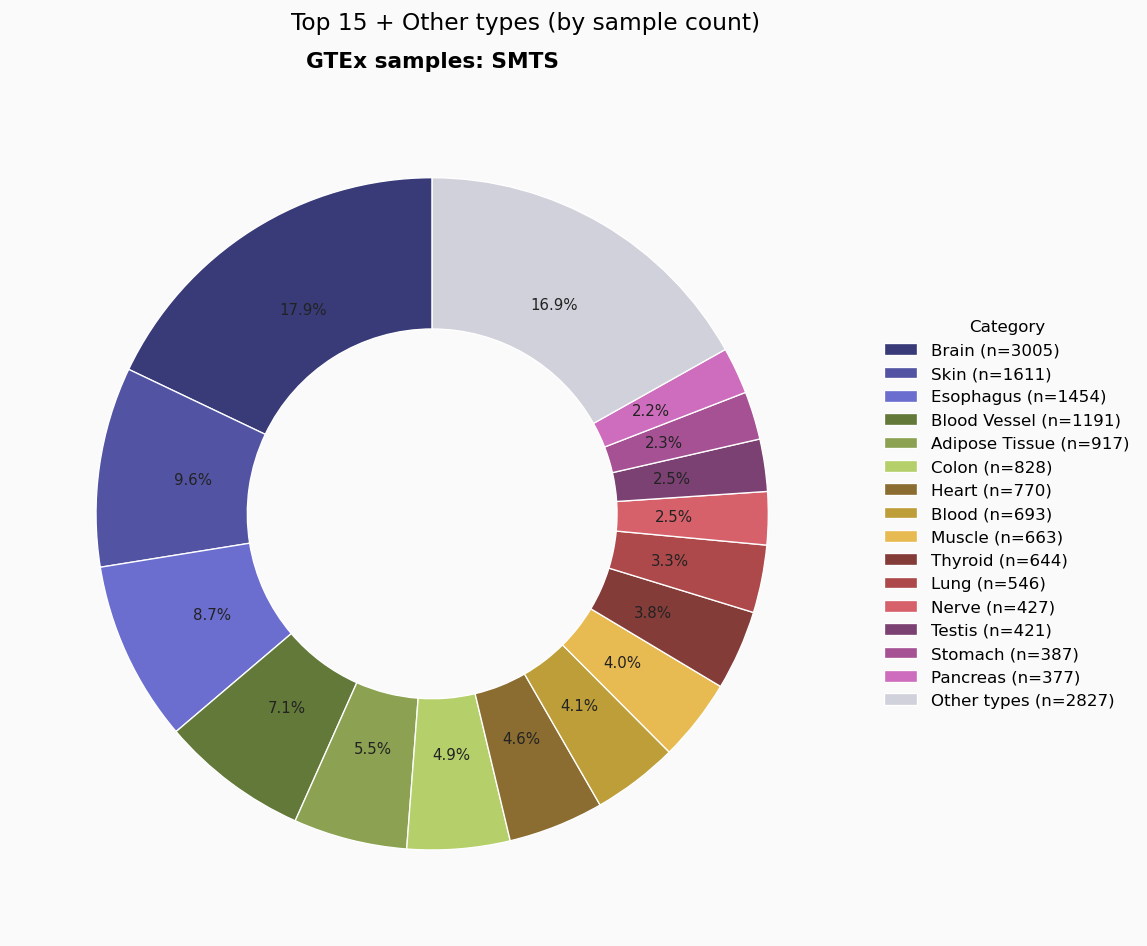

In [201]:
plot_pie_single(
    wide,
    "SMTS",
    title_prefix="GTEx samples",
    save_path="/Users/neuropromotion/Desktop/miRNA/bulk_review/pipeline_python/figures/gtex_pie.pdf"
)